# DDIM Deblurring

In [ ]:
import os
from pathlib import Path

# project root
PROJECT_ROOT = Path("/path/Sample-Adaptive-Diffusion-Steps")

# data
DATA_DIR = PROJECT_ROOT / "data" / "img_align_celeba"

# scratch cache
os.environ["HF_HOME"] = f"/scratch/{os.environ['USER']}/huggingface"
os.environ["TRANSFORMERS_CACHE"] = os.environ["HF_HOME"]
os.environ["HUGGINGFACE_HUB_CACHE"] = os.environ["HF_HOME"]

print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())
print("DATA_DIR exists:", DATA_DIR.exists())
print("HF_HOME:", os.environ["HF_HOME"])

# check a sample image
sample_img = DATA_DIR / "000001.jpg"
print("Sample image exists:", sample_img.exists())
print("Sample image path:", sample_img)

PROJECT_ROOT exists: True
DATA_DIR exists: True
HF_HOME: /scratch/hbbeth/huggingface
Sample image exists: True
Sample image path: /projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/img_align_celeba/000001.jpg


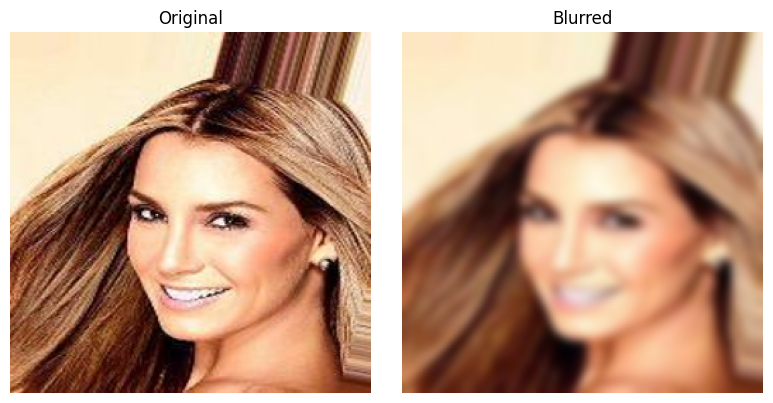

In [2]:
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

img_path = DATA_DIR / "000001.jpg"

img = Image.open(img_path).convert("RGB")
img = img.resize((256, 256))

blurred = img.filter(ImageFilter.GaussianBlur(radius=3))

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred)
plt.title("Blurred")
plt.axis("off")

plt.tight_layout()
plt.show()

### Converting images to tensors and setting up the blur

In [6]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
to_tensor = T.ToTensor()
to_pil = T.ToPILImage()

x0 = to_tensor(img).unsqueeze(0).to(device)
y = to_tensor(blurred).unsqueeze(0).to(device)

print("x0 shape:", x0.shape)
print("y shape:", y.shape)
print("device:", device)

x0 shape: torch.Size([1, 3, 256, 256])
y shape: torch.Size([1, 3, 256, 256])
device: cuda


In [8]:
import torch.nn.functional as F

def gaussian_kernel(kernel_size=9, sigma=3.0, channels=3, device="cuda"):
    coords = torch.arange(kernel_size, device=device) - kernel_size // 2
    x_grid, y_grid = torch.meshgrid(coords, coords, indexing="ij")
    kernel = torch.exp(-(x_grid**2 + y_grid**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    kernel = kernel.view(1, 1, kernel_size, kernel_size)
    kernel = kernel.repeat(channels, 1, 1, 1)
    return kernel

def blur_operator(x, kernel):
    pad = kernel.shape[-1] // 2
    return F.conv2d(x, kernel, padding=pad, groups=x.shape[1])

kernel = gaussian_kernel(kernel_size=9, sigma=3.0, channels=3, device=device)
y_check = blur_operator(x0, kernel)

print("kernel shape:", kernel.shape)
print("y_check shape:", y_check.shape)

kernel shape: torch.Size([3, 1, 9, 9])
y_check shape: torch.Size([1, 3, 256, 256])


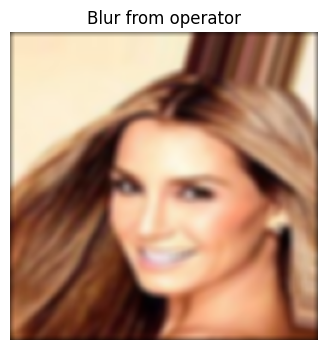

In [9]:
plt.figure(figsize=(4,4))
plt.imshow(to_pil(y_check.squeeze(0).cpu().clamp(0, 1)))
plt.title("Blur from operator")
plt.axis("off")
plt.show()

### Loading pretrained diffusion model 

In [10]:
from diffusers import DDPMPipeline, DDIMScheduler
import torch

pipe = DDPMPipeline.from_pretrained(
    "google/ddpm-celebahq-256"
).to(device)

unet = pipe.unet
scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

print("UNet loaded")

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /scratch/hbbeth/huggingface/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /scratch/hbbeth/huggingface/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


UNet loaded


In [11]:
num_steps = 50  # we will vary this later
scheduler.set_timesteps(num_steps)

timesteps = scheduler.timesteps
print("Timesteps:", len(timesteps))

Timesteps: 50


In [12]:
x_t = torch.randn_like(x0).to(device)

In [13]:
import torch
from tqdm.auto import tqdm

def restore_with_ddim_data_consistency(
    x_t,
    y,
    unet,
    scheduler,
    kernel,
    num_steps=50,
    dc_weight=0.1,
):
    scheduler.set_timesteps(num_steps)
    x = x_t.clone()

    for t in tqdm(scheduler.timesteps):
        with torch.no_grad():
            noise_pred = unet(x, t).sample

        # DDIM denoising step
        step_out = scheduler.step(noise_pred, t, x)
        x = step_out.prev_sample

        # Data consistency: make Ax closer to y
        x = x - dc_weight * (blur_operator(x, kernel) - y)

        # Keep values stable
        x = x.clamp(0, 1)

    return x

In [20]:
x_t = torch.randn_like(x0).to(device)

x_restored = restore_with_ddim_data_consistency(
    x_t=x_t,
    y=y,
    unet=unet,
    scheduler=scheduler,
    kernel=kernel,
    num_steps=20,
    dc_weight=0.1,
)

  0%|          | 0/20 [00:00<?, ?it/s]

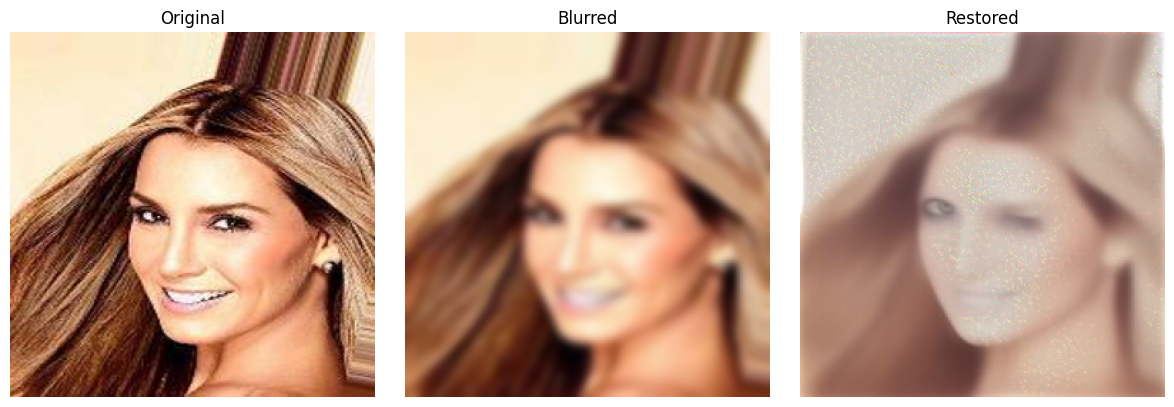

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(to_pil(x0.squeeze(0).cpu()))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(to_pil(y.squeeze(0).cpu()))
plt.title("Blurred")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(to_pil(x_restored.squeeze(0).detach().cpu()))
plt.title("Restored")
plt.axis("off")

plt.tight_layout()
plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

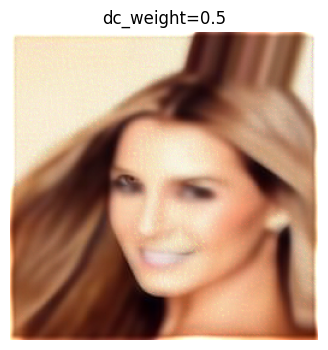

  0%|          | 0/20 [00:00<?, ?it/s]

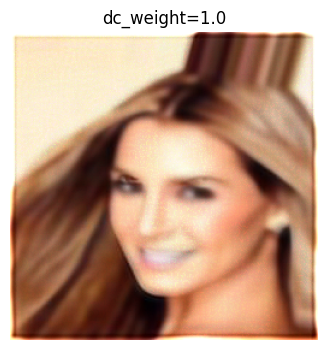

  0%|          | 0/20 [00:00<?, ?it/s]

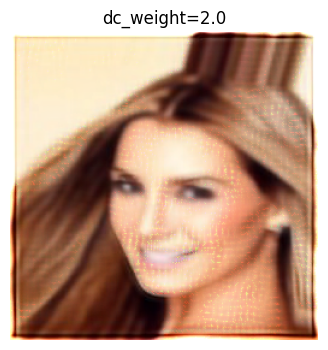

In [22]:
for w in [0.5, 1.0, 2.0]:
    x_restored = restore_with_ddim_data_consistency(
        x_t=torch.randn_like(x0),
        y=y,
        unet=unet,
        scheduler=scheduler,
        kernel=kernel,
        num_steps=20,
        dc_weight=w,
    )

    plt.figure(figsize=(4,4))
    plt.imshow(to_pil(x_restored.squeeze(0).detach().cpu()))
    plt.title(f"dc_weight={w}")
    plt.axis("off")
    plt.show()

We notice from above that blurred images do indeed contain useful information, with more weight given to data consistency the closer it is to the real image.

## Now measure LPIPS

In [23]:
import lpips
import torch

lpips_model = lpips.LPIPS(net='alex').to(device)
print("LPIPS ready")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /usr4/cs640/hbbeth/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:00<00:00, 387MB/s] 


Loading model from: /projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
LPIPS ready


In [24]:
def to_lpips_range(x):
    return x * 2 - 1

In [25]:
with torch.no_grad():
    score = lpips_model(
        to_lpips_range(x_restored.clamp(0, 1)),
        to_lpips_range(x0.clamp(0, 1))
    )

print("LPIPS score:", score.item())

LPIPS score: 0.42411407828330994


### Checking how LPIPS changes with varying step counts

In [26]:
step_list = [5, 10, 20, 30, 50]
results = []

for k in step_list:
    x_restored_k = restore_with_ddim_data_consistency(
        x_t=torch.randn_like(x0),
        y=y,
        unet=unet,
        scheduler=scheduler,
        kernel=kernel,
        num_steps=k,
        dc_weight=2.0,
    )

    with torch.no_grad():
        lp = lpips_model(
            to_lpips_range(x_restored_k.clamp(0, 1)),
            to_lpips_range(x0.clamp(0, 1))
        ).item()

    results.append((k, lp, x_restored_k.detach().cpu()))
    print(f"steps={k}, LPIPS={lp:.4f}")

  0%|          | 0/5 [00:00<?, ?it/s]

steps=5, LPIPS=0.6507


  0%|          | 0/10 [00:00<?, ?it/s]

steps=10, LPIPS=0.4741


  0%|          | 0/20 [00:00<?, ?it/s]

steps=20, LPIPS=0.4204


  0%|          | 0/30 [00:00<?, ?it/s]

steps=30, LPIPS=0.4371


  0%|          | 0/50 [00:00<?, ?it/s]

steps=50, LPIPS=0.6709


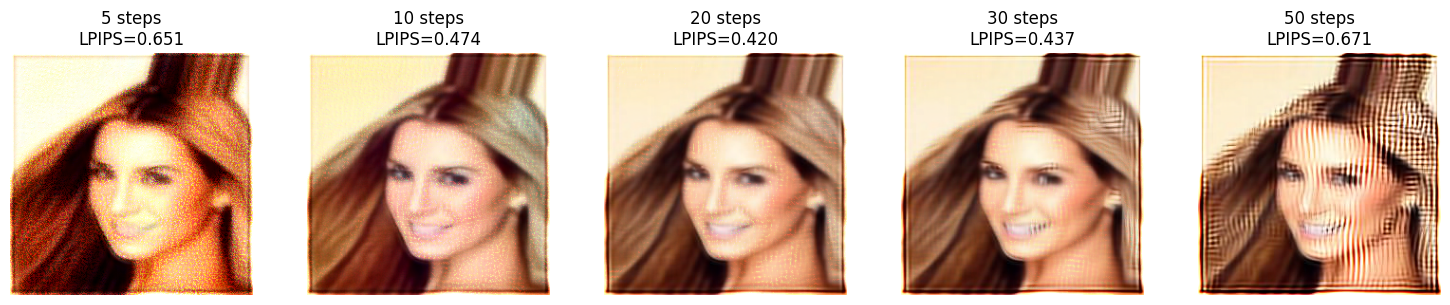

In [27]:
plt.figure(figsize=(15, 3))
for i, (k, lp, x_img) in enumerate(results):
    plt.subplot(1, len(results), i + 1)
    plt.imshow(to_pil(x_img.squeeze(0).clamp(0, 1)))
    plt.title(f"{k} steps\nLPIPS={lp:.3f}")
    plt.axis("off")
plt.tight_layout()
plt.show()

The experiment above indicates the images have an optimal step count

## Quick fine-tuning to see if this model can be improved

In [28]:
step_list = [10, 20, 30]
dc_list = [1.0, 2.0, 3.0, 4.0]

best = None
all_results = []

for k in step_list:
    for w in dc_list:
        x_restored_kw = restore_with_ddim_data_consistency(
            x_t=torch.randn_like(x0),
            y=y,
            unet=unet,
            scheduler=scheduler,
            kernel=kernel,
            num_steps=k,
            dc_weight=w,
        )

        with torch.no_grad():
            lp = lpips_model(
                to_lpips_range(x_restored_kw.clamp(0, 1)),
                to_lpips_range(x0.clamp(0, 1))
            ).item()

        all_results.append((k, w, lp, x_restored_kw.detach().cpu()))
        print(f"steps={k}, dc_weight={w}, LPIPS={lp:.4f}")

        if best is None or lp < best[2]:
            best = (k, w, lp, x_restored_kw.detach().cpu())

print("\nBest:", best[0], "steps,", "dc_weight=", best[1], ", LPIPS=", best[2])

  0%|          | 0/10 [00:00<?, ?it/s]

steps=10, dc_weight=1.0, LPIPS=0.5047


  0%|          | 0/10 [00:00<?, ?it/s]

steps=10, dc_weight=2.0, LPIPS=0.4750


  0%|          | 0/10 [00:00<?, ?it/s]

...

steps=30, dc_weight=2.0, LPIPS=0.4666


  0%|          | 0/30 [00:00<?, ?it/s]

steps=30, dc_weight=3.0, LPIPS=0.7963


  0%|          | 0/30 [00:00<?, ?it/s]

steps=30, dc_weight=4.0, LPIPS=0.8004

Best: 20 steps, dc_weight= 1.0 , LPIPS= 0.4142957925796509


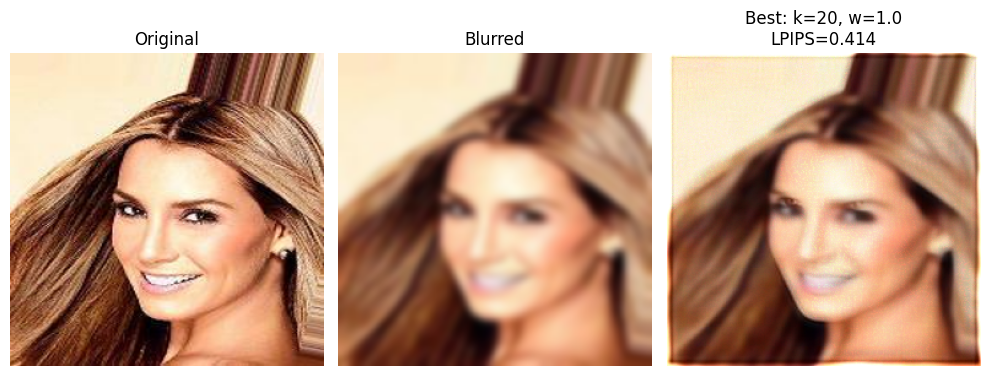

In [29]:
best_k, best_w, best_lp, best_img = best

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(to_pil(x0.squeeze(0).cpu()))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(to_pil(y.squeeze(0).cpu()))
plt.title("Blurred")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(to_pil(best_img.squeeze(0).clamp(0, 1)))
plt.title(f"Best: k={best_k}, w={best_w}\nLPIPS={best_lp:.3f}")
plt.axis("off")

plt.tight_layout()
plt.show()

This hand-made simple restoration model has proven to be a sanity check, now we will move to a stronger model